## Tahap 5 — Visualisasi & Business Insight

Visualisasi yang saya buat:
1. Bar chart distribusi segmen (jumlah pelanggan & % revenue)
2. Scatter plot R vs M berwarna per segmen
3. Heatmap rata-rata skor RFM per segmen
4. Tabel rekomendasi strategi marketing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

rfm = pd.read_csv('../data/rfm_result_pbi.csv')
print(f'Data loaded: {len(rfm):,} pelanggan')
rfm['Segment'].value_counts()

Data loaded: 5,861 pelanggan


Segment
Lost               1894
Loyal Customers    1395
Champions          1293
At Risk             828
New Customers       451
Name: count, dtype: int64

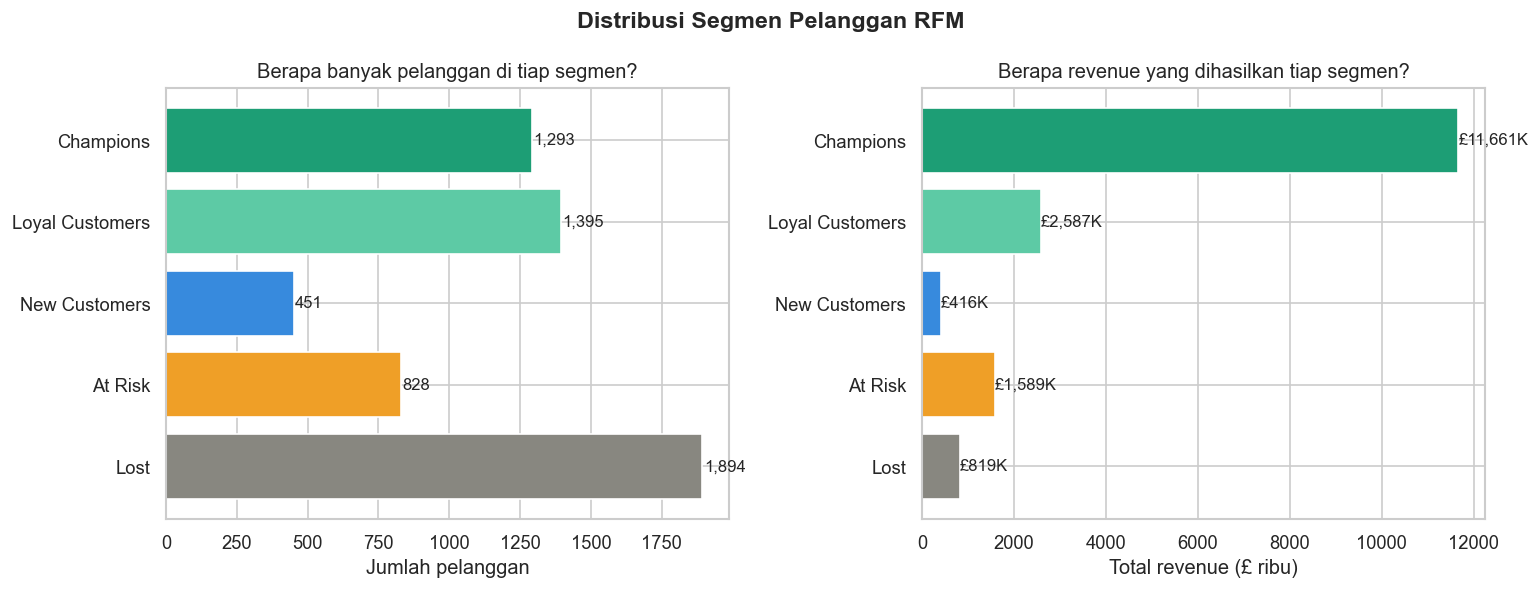

In [3]:
# ── Chart 1: Distribusi segmen ───────────────────────────────────────────────
seg_order  = ['Champions', 'Loyal Customers', 'New Customers', 'At Risk', 'Lost']
seg_colors = {'Champions':'#1D9E75', 'Loyal Customers':'#5DCAA5',
               'New Customers':'#378ADD', 'At Risk':'#EF9F27', 'Lost':'#888780'}

seg_count = rfm['Segment'].value_counts().reindex(seg_order)
seg_rev   = rfm.groupby('Segment')['Monetary'].sum().reindex(seg_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Segmen Pelanggan RFM', fontsize=14, fontweight='bold')

# Jumlah pelanggan
bars = axes[0].barh(seg_order[::-1], seg_count.values[::-1],
                    color=[seg_colors[s] for s in seg_order[::-1]])
axes[0].set_xlabel('Jumlah pelanggan')
axes[0].set_title('Berapa banyak pelanggan di tiap segmen?')
for bar, val in zip(bars, seg_count.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

# Revenue kontribusi
bars2 = axes[1].barh(seg_order[::-1], seg_rev.values[::-1] / 1000,
                     color=[seg_colors[s] for s in seg_order[::-1]])
axes[1].set_xlabel('Total revenue (£ ribu)')
axes[1].set_title('Berapa revenue yang dihasilkan tiap segmen?')
for bar, val in zip(bars2, seg_rev.values[::-1]):
    axes[1].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'£{val/1000:,.0f}K', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart_01_distribusi.png', bbox_inches='tight')
plt.show()

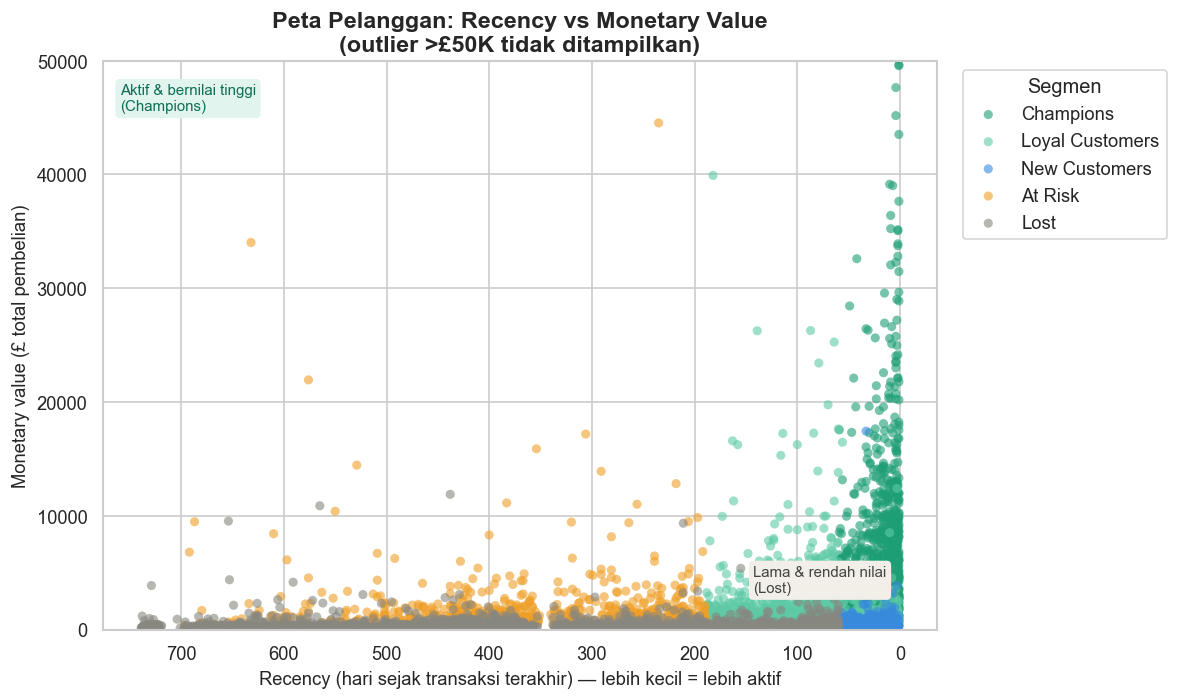

In [4]:
# ── Chart 2: Scatter plot Recency vs Monetary ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Peta Pelanggan: Recency vs Monetary Value',
             fontsize=14, fontweight='bold')

for seg in seg_order:
    subset = rfm[rfm['Segment'] == seg]
    ax.scatter(subset['Recency'], subset['Monetary'],
               c=seg_colors[seg], label=seg,
               alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel('Recency (hari sejak transaksi terakhir) — lebih kecil = lebih aktif', fontsize=11)
ax.set_ylabel('Monetary value (£ total pembelian)', fontsize=11)
ax.legend(title='Segmen', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.invert_xaxis()

# Anotasi kuadran
ax.text(0.02, 0.96, 'Aktif & bernilai tinggi\n(Champions)',
        transform=ax.transAxes, va='top', fontsize=9, color='#0F6E56',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E1F5EE', edgecolor='none'))
ax.text(0.78, 0.06, 'Lama & rendah nilai\n(Lost)',
        transform=ax.transAxes, va='bottom', fontsize=9, color='#444441',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F1EFE8', edgecolor='none'))
ax.set_ylim(0, 50000)
ax.set_title('Peta Pelanggan: Recency vs Monetary Value\n(outlier >£50K tidak ditampilkan)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_02_scatter.png', bbox_inches='tight')
plt.show()

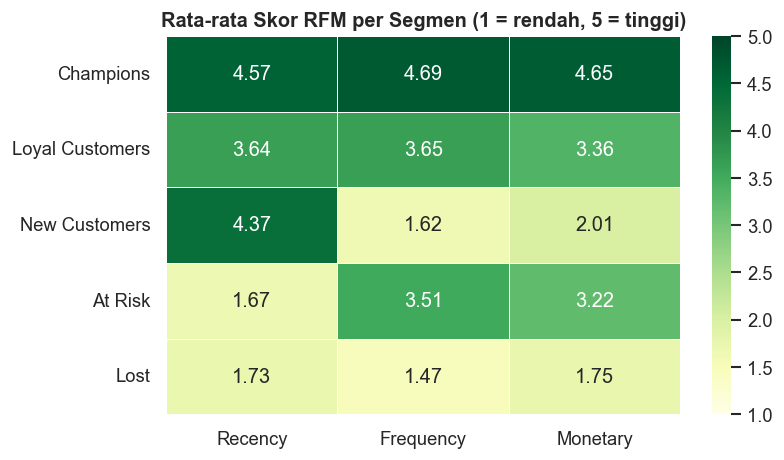

In [5]:
# ── Chart 3: Heatmap rata-rata skor RFM per segmen ──────────────────────────
heatmap_data = rfm.groupby('Segment')[['R_score','F_score','M_score']].mean()\
                   .reindex(seg_order)\
                   .rename(columns={'R_score':'Recency',
                                    'F_score':'Frequency',
                                    'M_score':'Monetary'})

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            vmin=1, vmax=5, ax=ax)
ax.set_title('Rata-rata Skor RFM per Segmen (1 = rendah, 5 = tinggi)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart_03_heatmap.png', bbox_inches='tight')
plt.show()

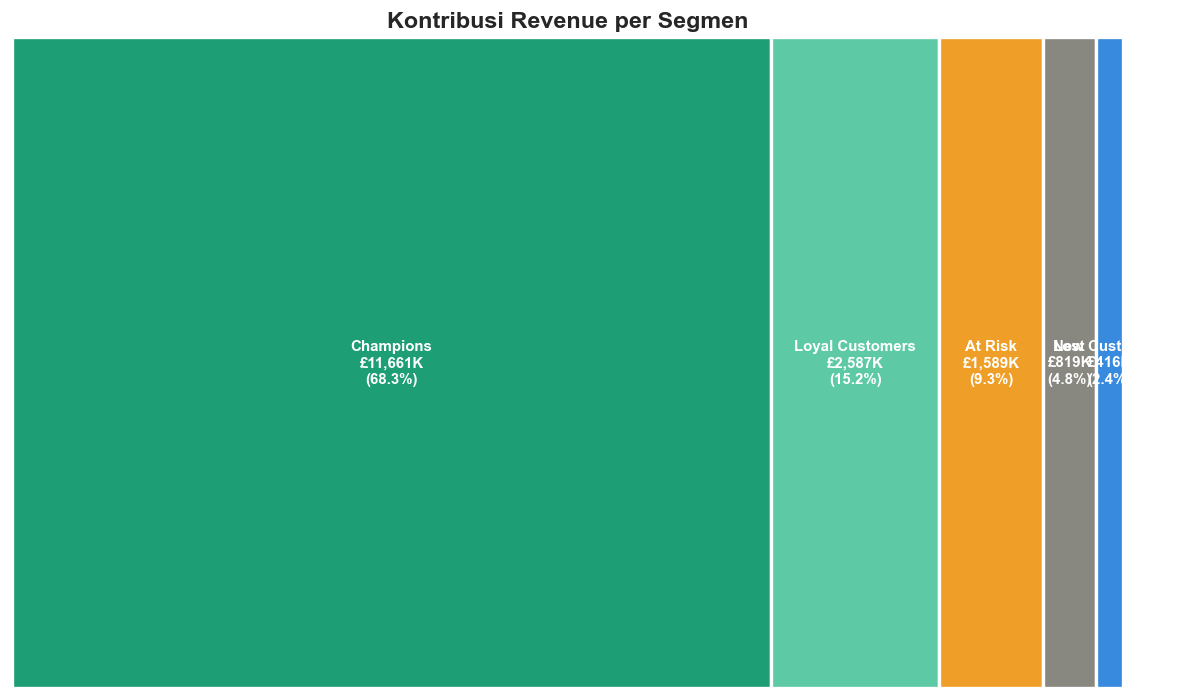

In [6]:
# ── Chart 4: Treemap revenue per segmen ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sizes  = seg_rev.values
colors = [seg_colors[s] for s in seg_order]
labels = [f'{s}\n£{v/1000:,.0f}K\n({v/seg_rev.sum()*100:.1f}%)'
          for s, v in zip(seg_order, sizes)]

import matplotlib.patches as mpatches
x, y, w, h = 0, 0, 10, 6
rects = []
remaining = list(zip(sizes, labels, colors))
remaining.sort(reverse=True)

def draw_rect(ax, x, y, w, h, color, label):
    rect = plt.Rectangle((x, y), w, h, color=color, ec='white', lw=2)
    ax.add_patch(rect)
    fontsize = 9 if (w * 10) > 1 else 7
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')
total = sum(sizes)
cx = 0
for size, label, color in remaining:
    bw = (size / total) * 10
    draw_rect(ax, cx, 0, bw, 6, color, label)
    cx += bw

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Kontribusi Revenue per Segmen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_treemap.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Tabel strategi bisnis ────────────────────────────────────────────────────
strategy = pd.DataFrame({
    'Segmen'          : seg_order,
    'Jumlah'          : seg_count.values,
    '% Revenue'       : (seg_rev / seg_rev.sum() * 100).round(1).astype(str) + '%',
    'Prioritas'       : ['Sangat Tinggi','Tinggi','Sedang','Tinggi','Rendah'],
    'Rekomendasi Aksi': [
        'Program loyalti eksklusif, early access produk baru, referral reward',
        'Upsell & cross-sell, membership tier, diskon ulang tahun',
        'Email onboarding, diskon pembelian kedua, nudge produk terlaris',
        'Win-back campaign, voucher kembali, survey alasan berhenti beli',
        'Stop iklan, alihkan budget ke segmen prioritas'
    ]
})

print(strategy.to_string(index=False))
strategy.to_csv('../data/rfm_strategy.csv', index=False)
print('\nTabel strategi disimpan.')

         Segmen  Jumlah % Revenue     Prioritas                                                     Rekomendasi Aksi
      Champions    1293     68.3% Sangat Tinggi Program loyalti eksklusif, early access produk baru, referral reward
Loyal Customers    1395     15.2%        Tinggi             Upsell & cross-sell, membership tier, diskon ulang tahun
  New Customers     451      2.4%        Sedang      Email onboarding, diskon pembelian kedua, nudge produk terlaris
        At Risk     828      9.3%        Tinggi      Win-back campaign, voucher kembali, survey alasan berhenti beli
           Lost    1894      4.8%        Rendah                       Stop iklan, alihkan budget ke segmen prioritas

Tabel strategi disimpan.


## Key Insights & Business Recommendation

### Insight 1 — Pareto Ekstrem: 22% Pelanggan Menghasilkan 68% Revenue
Champions hanya 1.292 orang dari 5.861 total pelanggan, namun menghasilkan £11.659.388 dari total £17.072.834 revenue. Ini jauh melampaui aturan Pareto 80/20 yang umum. bisnis ini memiliki ketergantungan tinggi pada segelintir pelanggan. Rata-rata Champions membeli 17x dengan recency hanya 20 hari, menunjukkan loyalitas yang sangat tinggi. Kehilangan 10% Champions saja berpotensi mengurangi revenue hingga £1.1M.

### Insight 2 — At Risk: Peluang Recovery £1.5M yang Sering Diabaikan
828 pelanggan At Risk rata-rata sudah tidak bertransaksi selama 369 hari, padahal rata-rata spending mereka £1.920 per pelanggan — hampir setara dengan Loyal Customers £1.854). Mereka dulunya aktif (avg frequency 5x), artinya bukan pelanggan sembarangan. Win-back campaign dengan voucher 15–20% berpotensi me-recover sebagian dari £1.589.286 revenue segmen ini sebelum mereka benar-benar Lost.

### Insight 3 — New Customers Berisiko Churn Sebelum Jadi Loyal
451 New Customers hanya menyumbang 2.4% revenue (£416.406) dengan rata-rata baru 1.5 transaksi dan recency 28 hari — mereka masih aktif tapi belum terikat. Tanpa onboarding yang terstruktur, mayoritas kemungkinan besar akan masuk ke segmen Lost di periode berikutnya. Email series + insentif pembelian kedua adalah intervensi paling kritis untuk segmen ini.

### Insight 4 — Lost Menguras Perhatian Tanpa Hasil Signifikan
Lost adalah segmen terbesar (1.894 pelanggan, 32.3% dari total basis) namun hanya menghasilkan 4.8% revenue (£819.267) dengan rata-rata recency 388 hari dan hanya 1.3x transaksi. Profil ini menunjukkan mereka memang pelanggan one-time buyer yang tidak pernah kembali — bukan pelanggan aktif yang berhenti. Mengalihkan budget marketing dari segmen ini ke Champions retention dan At Risk win-back adalah keputusan paling efisien secara ROI.

### Insight 5 — Pola RFM Score Mengkonfirmasi Validitas Segmentasi
Distribusi skor RFM sangat bersih dan konsisten: Champions mendominasi di semua dimensi (R_score tinggi, F_score tinggi, M_score tinggi). At Risk menunjukkan pola unik — F_score dan M_score tinggi tapi R_score sangat rendah — mengkonfirmasi bahwa mereka adalah pelanggan yang dulu aktif dan bernilai tinggi, bukan pelanggan baru yang underperform. Ini memperkuat bahwa win-back campaign untuk At Risk memiliki probabilitas konversi lebih tinggi dibanding akuisisi pelanggan baru.

---

### Rekomendasi Prioritas untuk Tim Marketing

| Prioritas | Segmen | Aksi | Estimasi Impact |
|---|---|---|---|
| 1 | Champions (1292) | Program loyalti eksklusif, early access produk baru, VIP tier | Pertahankan £11.7M (68% revenue) |
| 2 | At Risk (828) | Win-back campaign, voucher 15–20%, personal outreach | Potensi recovery hingga £1.5M |
| 3 | New Customers (451) | Email onboarding series, diskon pembelian kedua | Konversi ke Loyal, cegah churn |
| 4 | Loyal Customers (1396) | Upsell & cross-sell, program referral | Tingkatkan dari £2.6M ke Champions tier |
| 5 | Lost (1894) | Stop paid ads, minimal spend, fokus budget ke atas | Efisiensi budget marketing |

In [8]:
import pandas as pd
rfm = pd.read_csv('../data/rfm_result_pbi.csv')
summary = rfm.groupby('Segment').agg(
    Jumlah=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum')
)
summary['Pct_Pelanggan'] = (summary['Jumlah'] / len(rfm) * 100).round(1)
summary['Pct_Revenue'] = (summary['Total_Revenue'] / rfm['Monetary'].sum() * 100).round(1)
print(summary)
print(f'\nTotal pelanggan: {len(rfm):,}')
print(f'Total revenue: £{rfm["Monetary"].sum():,}')

                 Jumlah  Total_Revenue  Pct_Pelanggan  Pct_Revenue
Segment                                                           
At Risk             828        1589286           14.1          9.3
Champions          1293       11660589           22.1         68.3
Lost               1894         819267           32.3          4.8
Loyal Customers    1395        2587286           23.8         15.2
New Customers       451         416406            7.7          2.4

Total pelanggan: 5,861
Total revenue: £17,072,834
